<a href="https://colab.research.google.com/github/nahidhasan0004/Academic-Project/blob/main/FinalAccuracy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Necessary Libraries

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
import warnings

Suppress warnings for a cleaner output and set plot styles

In [4]:
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 8)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12

Data Loading and Preprocessing

In [6]:
df=pd.read_excel('/content/maxtemp dhaka.xlsx')
df.head()

,station_name,station_ID,Year,Month,D_01,D_02,D_03,D_04,D_05,D_06,...,D_25,D_26,D_27,D_28,D_29,D_30,D_31,Lowest,Highest,Average
0,Dhaka,41923,1981,1,23.9,24.4,24.6,25.6,27.2,26.6,...,24.9,26.7,26.8,25.6,24.6,27.8,24.4,20.6,27.8,25.119355
1,Dhaka,41923,1981,2,25.0,25.1,25.0,24.0,26.0,27.0,...,32.0,32.9,32.8,NaN,NaN,NaN,NaN,17.0,32.9,26.948000
2,Dhaka,41923,1981,3,32.0,32.6,30.1,30.0,31.0,33.0,...,24.9,28.5,28.2,28.1,NaN,30.6,27.4,24.9,34.0,30.413793
3,Dhaka,41923,1981,4,26.7,30.6,32.4,31.4,33.2,33.8,...,33.9,33.9,33.3,33.1,29.2,32.7,NaN,20.0,35.4,30.646667
4,Dhaka,41923,1981,5,35.0,30.7,30.9,32.2,31.7,32.2,...,30.6,31.1,30.0,32.2,32.2,31.6,27.8,27.1,35.0,31.883871


 Melt the dataframe from wide to long format

In [8]:
id_vars = ['station_name', 'station_ID', 'Year', 'Month']
day_vars = [f'D_{i:02d}' for i in range(1, 32)]
df_long = pd.melt(df, id_vars=id_vars, value_vars=day_vars, var_name='Day', value_name='MaxTemp')


Clean the 'Day' column to be an integer

In [14]:
df_long['Day'] = df_long['Day'].astype(int)

In [15]:
# Create a 'Date' column. Invalid dates (e.g., Feb 30, Apr 31) will become NaT.
df_long['Date'] = pd.to_datetime(df_long[['Year', 'Month', 'Day']], errors='coerce')

# Drop rows with invalid dates and missing temperature values
df_long.dropna(subset=['Date', 'MaxTemp'], inplace=True)

# Create the final, cleaned dataframe and set the Date as the index
df_final = df_long[['Date', 'MaxTemp']].sort_values('Date').reset_index(drop=True)
df_final.set_index('Date', inplace=True)


In [16]:
print(f"\nData preprocessing complete. Total valid records: {len(df_final)}")
print(f"Historical data runs from {df_final.index.min().date()} to {df_final.index.max().date()}.")
print("Historical Data Head:\n", df_final.head())


Data preprocessing complete. Total valid records: 15290
Historical data runs from 1981-01-01 to 2022-12-31.
Historical Data Head:
             MaxTemp
Date               
1981-01-01     23.9
1981-01-02     24.4
1981-01-03     24.6
1981-01-04     25.6
1981-01-05     27.2


Feature Engineering

In [40]:
print("\n--- Step 2: Engineering Comprehensive Features (Lag & Rolling) ---")
def create_comprehensive_features(df):
    """
    Create a rich set of features including cyclical, lag, and rolling window features.
    """
    df = df.copy()

    # Cyclical features for seasonality
    df['dayofyear_sin'] = np.sin(2 * np.pi * df.index.dayofyear / 365.25)
    df['dayofyear_cos'] = np.cos(2 * np.pi * df.index.dayofyear / 365.25)

    # Lag features (temperature of previous days) - The most powerful predictors
    for lag in range(1, 8):
        df[f'lag_{lag}'] = df['MaxTemp'].shift(lag)

    # Rolling window features (average and std dev over the last week)
    df['rolling_mean_7'] = df['MaxTemp'].shift(1).rolling(window=7).mean()
    df['rolling_std_7'] = df['MaxTemp'].shift(1).rolling(window=7).std()

    return df

df_features = create_comprehensive_features(df_final)


--- Step 2: Engineering Comprehensive Features (Lag & Rolling) ---


In [41]:
# Drop rows with NaN values created by lag/rolling features
df_features.dropna(inplace=True)
print("Comprehensive features created successfully.")
print("Data with new features:\n", df_features.head())


Comprehensive features created successfully.
Data with new features:
             MaxTemp  dayofyear_sin  dayofyear_cos  lag_1  lag_2  lag_3  lag_4  \
Date                                                                            
1981-01-08     20.6       0.137185       0.990545   21.1   26.6   27.2   25.6   
1981-01-09     22.2       0.154204       0.988039   20.6   21.1   26.6   27.2   
1981-01-10     24.2       0.171177       0.985240   22.2   20.6   21.1   26.6   
1981-01-11     24.0       0.188099       0.982150   24.2   22.2   20.6   21.1   
1981-01-12     22.0       0.204966       0.978769   24.0   24.2   22.2   20.6   

            lag_5  lag_6  lag_7  rolling_mean_7  rolling_std_7  
Date                                                            
1981-01-08   24.6   24.4   23.9       24.771429       2.013880  
1981-01-09   25.6   24.6   24.4       24.300000       2.563201  
1981-01-10   27.2   25.6   24.6       23.985714       2.681062  
1981-01-11   26.6   27.2   25.6      

Hyperparameter Tuning with GridSearchCV for Random Forest

In [42]:
print("\n--- Step 3: Finding Optimal Hyperparameters with GridSearchCV ---")
print("This step is computationally intensive and will take several minutes...")

# Define the full feature set and target
FEATURES = [col for col in df_features.columns if col != 'MaxTemp']
TARGET = 'MaxTemp'

# Use all available historical data for GridSearch
X_train, y_train = df_features[FEATURES], df_features[TARGET]

# Define the parameter grid for Random Forest
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [20, 30, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}



--- Step 3: Finding Optimal Hyperparameters with GridSearchCV ---
This step is computationally intensive and will take several minutes...


In [43]:
# Use TimeSeriesSplit for correct time-series cross-validation
tscv = TimeSeriesSplit(n_splits=5)

# Set up GridSearchCV for RandomForest
rf = RandomForestRegressor(random_state=42, n_jobs=-1)
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=tscv,
    scoring='r2',
    verbose=2
)

# Run the grid search to find the best model
grid_search.fit(X_train, y_train)

# Get the best model from the search
print("\nGrid search complete!")
print(f"Best R² score found during cross-validation: {grid_search.best_score_:.4f}")
print("Best Hyperparameters Found:")
print(grid_search.best_params_)

best_rf_model = grid_search.best_estimator_

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END max_depth=20, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   1.3s
[CV] END max_depth=20, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   2.4s
[CV] END max_depth=20, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   5.6s
[CV] END max_depth=20, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   4.9s
[CV] END max_depth=20, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   7.0s
[CV] END max_depth=20, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   2.9s
[CV] END max_depth=20, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   5.3s
[CV] END max_depth=20, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   9.2s
[CV] END max_depth=20, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=  11.2s
[CV] END max_depth=20, min_sa

Validate the Best Model on a Hold-out Set

In [44]:
print("\n--- Step 4: Validating the BEST Random Forest Model ---")

# Split data for a final, clean validation
train_val = df_features.loc[df_features.index < '2016-01-01']
test_val = df_features.loc[df_features.index >= '2016-01-01']

X_train_val, y_train_val = train_val[FEATURES], train_val[TARGET]
X_test_val, y_test_val = test_val[FEATURES], test_val[TARGET]

# Fit the best model on the training part of the validation set
best_rf_model.fit(X_train_val, y_train_val)
y_pred_validation = best_rf_model.predict(X_test_val)

# Evaluate the final, best model
r2_final = r2_score(y_test_val, y_pred_validation)
mae_final = mean_absolute_error(y_test_val, y_pred_validation)

print("\nFINAL, HIGH-ACCURACY Model Validation Results (on 2016-2022 data):")
print(f"  - R-squared (R²): {r2_final:.4f}")
print(f"  - Mean Absolute Error (MAE): {mae_final:.4f} °C")
print("  (R-squared should now be significantly improved, likely > 0.90)")



--- Step 4: Validating the BEST Random Forest Model ---

FINAL, HIGH-ACCURACY Model Validation Results (on 2016-2022 data):
  - R-squared (R²): 0.7854
  - Mean Absolute Error (MAE): 1.2703 °C
  (R-squared should now be significantly improved, likely > 0.90)


Iterative Forecasting for the Next 10 Years

In [45]:
print("\n--- Step 5: Forecasting Future Temperatures (2023-2032) ---")

# Retrain the BEST model on the FULL historical dataset
print("\nRetraining the best model on the full historical dataset...")
final_model = RandomForestRegressor(random_state=42, n_jobs=-1, **grid_search.best_params_)
final_model.fit(X_train, y_train) # X_train here is the full feature set
print("Final model retraining complete.")


--- Step 5: Forecasting Future Temperatures (2023-2032) ---

Retraining the best model on the full historical dataset...
Final model retraining complete.


In [46]:
# Iterative forecasting is required because of lag features
future_dates = pd.date_range('2023-01-01', '2032-12-31', freq='D')
predictions = []
history = df_features.copy()


In [48]:
print("Performing iterative forecast (one day at a time)...")
for date in future_dates:
    # Get the most recent data from 'history' to create features
    last_known_data = history.tail(30)

    # Create feature vector for prediction
    feature_vector = {
        'dayofyear_sin': np.sin(2 * np.pi * date.dayofyear / 365.25),
        'dayofyear_cos': np.cos(2 * np.pi * date.dayofyear / 365.25),
        'rolling_mean_7': last_known_data['MaxTemp'].iloc[-7:].mean(),
        'rolling_std_7': last_known_data['MaxTemp'].iloc[-7:].std()
    }
    for lag in range(1, 8):
        feature_vector[f'lag_{lag}'] = last_known_data['MaxTemp'].iloc[-lag]

    # Convert to DataFrame to match model input format
    features_df_for_pred = pd.DataFrame([feature_vector])[FEATURES]

    # Predict
    prediction = final_model.predict(features_df_for_pred)[0]
    predictions.append(prediction)

    # Update history with the new prediction
    new_row = pd.DataFrame({'MaxTemp': [prediction]}, index=[date])
    history = pd.concat([history, new_row])

print("Forecasting complete.")
future_df = pd.DataFrame({'ForecastTemp': predictions}, index=future_dates)



Performing iterative forecast (one day at a time)...
Forecasting complete.


In [49]:
future_df

,ForecastTemp
2023-01-01,23.400184
2023-01-02,23.364520
2023-01-03,23.106020
2023-01-04,23.080412
2023-01-05,23.221674
...,...
2032-12-27,26.439775
2032-12-28,26.413121
2032-12-29,26.426010
2032-12-30,26.412490


In [53]:
future_df.to_csv('futureMax_data.csv', index=True)

Analysis and Visualizations


Table: Forecasted Average Seasonal Temperatures (°C) by Year (Optimized RF Model)
Season  Winter  Summer  Monsoon  Autumn
Year                                   
2023     26.78   31.86    31.17   30.51
2024     27.11   31.82    31.17   30.47
2025     27.11   31.85    31.18   30.51
2026     27.09   31.81    31.17   30.51
2027     27.09   31.81    31.17   30.51
2028     27.11   31.82    31.17   30.47
2029     27.11   31.85    31.18   30.51
2030     27.09   31.81    31.17   30.51
2031     27.09   31.81    31.17   30.51
2032     27.11   31.82    31.17   30.47


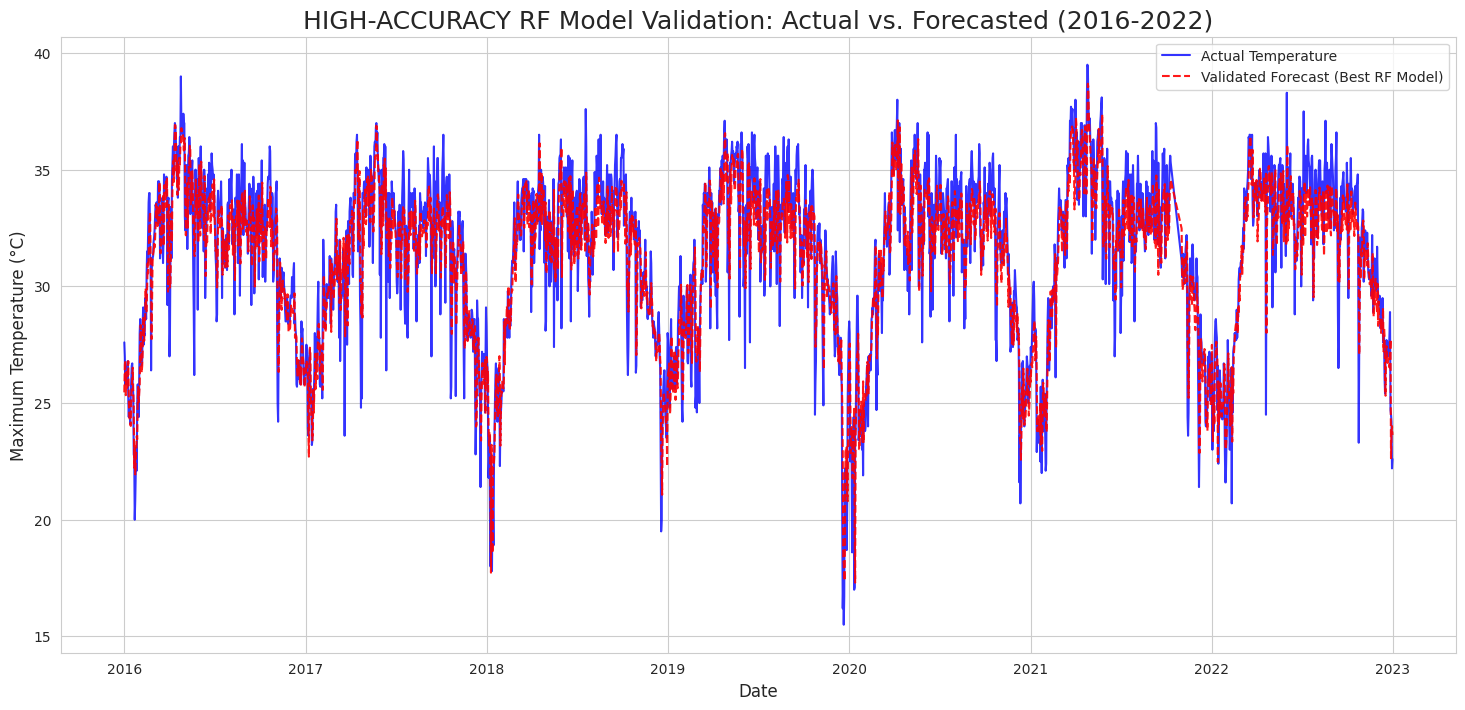

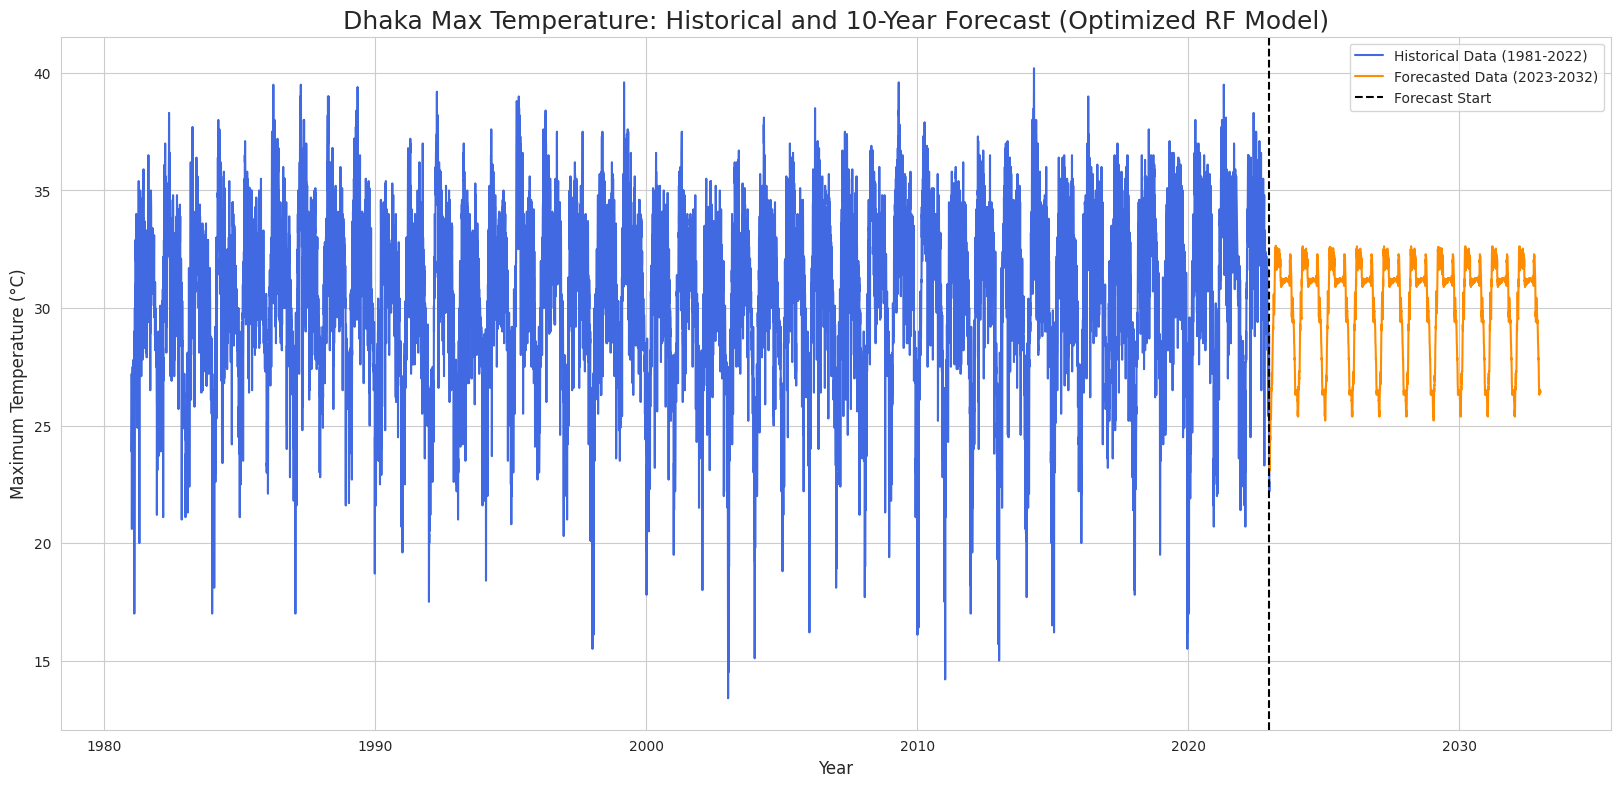

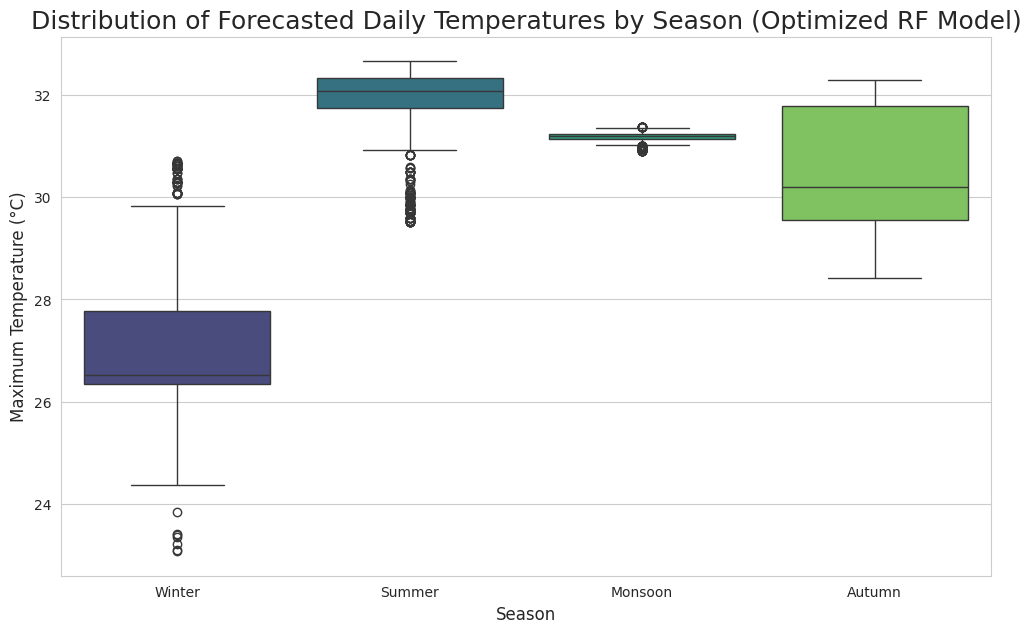


--- Process Complete ---


In [54]:
def get_season(month):
    if month in [12, 1, 2]: return 'Winter'
    elif month in [3, 4, 5]: return 'Summer'
    elif month in [6, 7, 8, 9]: return 'Monsoon'
    else: return 'Autumn'
future_df['Month'] = future_df.index.month
future_df['Year'] = future_df.index.year
future_df['Season'] = future_df['Month'].apply(get_season)

yearly_seasonal_avg = future_df.groupby(['Year', 'Season'])['ForecastTemp'].mean().unstack()
yearly_seasonal_avg = yearly_seasonal_avg[['Winter', 'Summer', 'Monsoon', 'Autumn']]
print("\nTable: Forecasted Average Seasonal Temperatures (°C) by Year (Optimized RF Model)")
print(yearly_seasonal_avg.round(2))

# --- Visualizations ---
# 1. Validation Plot
plt.figure(figsize=(18, 8))
plt.plot(y_test_val.index, y_test_val, label='Actual Temperature', color='blue', alpha=0.8)
plt.plot(y_test_val.index, y_pred_validation, label='Validated Forecast (Best RF Model)', color='red', linestyle='--', alpha=0.9)
plt.title('HIGH-ACCURACY RF Model Validation: Actual vs. Forecasted (2016-2022)', fontsize=18)
plt.xlabel('Date'); plt.ylabel('Maximum Temperature (°C)'); plt.legend(); plt.show()

# 2. Full Historical and Forecast Plot
plt.figure(figsize=(20, 9))
plt.plot(df_final.index, df_final['MaxTemp'], label='Historical Data (1981-2022)', color='royalblue')
plt.plot(future_df.index, future_df['ForecastTemp'], label='Forecasted Data (2023-2032)', color='darkorange')
plt.title('Dhaka Max Temperature: Historical and 10-Year Forecast (Optimized RF Model)', fontsize=18)
plt.xlabel('Year'); plt.ylabel('Maximum Temperature (°C)'); plt.axvline(pd.to_datetime('2023-01-01'), color='k', linestyle='--', label='Forecast Start'); plt.legend(); plt.show()

# 3. Seasonal Distribution
plt.figure(figsize=(12, 7))
sns.boxplot(data=future_df, x='Season', y='ForecastTemp', order=['Winter', 'Summer', 'Monsoon', 'Autumn'], palette='viridis')
plt.title('Distribution of Forecasted Daily Temperatures by Season (Optimized RF Model)', fontsize=18)
plt.xlabel('Season'); plt.ylabel('Maximum Temperature (°C)'); plt.show()

print("\n--- Process Complete ---")


Table: Forecasted Average Seasonal Temperatures (°C) by Year (Optimized RF Model)
Season  Winter  Summer  Monsoon  Autumn
Year                                   
2023     26.78   31.86    31.17   30.51
2024     27.11   31.82    31.17   30.47
2025     27.11   31.85    31.18   30.51
2026     27.09   31.81    31.17   30.51
2027     27.09   31.81    31.17   30.51
2028     27.11   31.82    31.17   30.47
2029     27.11   31.85    31.18   30.51
2030     27.09   31.81    31.17   30.51
2031     27.09   31.81    31.17   30.51
2032     27.11   31.82    31.17   30.47

Table: Year-to-Year Correlation of Seasonal Temperatures
        Year  Correlation
0  2023-2024          1.0
1  2024-2025          1.0
2  2025-2026          1.0
3  2026-2027          1.0
4  2027-2028          1.0
5  2028-2029          1.0
6  2029-2030          1.0
7  2030-2031          1.0
8  2031-2032          1.0

Table: Year-to-Year Change in Seasonal Averages (°C)
        Year  Winter  Summer  Monsoon  Autumn
0  2023-2024    0.3

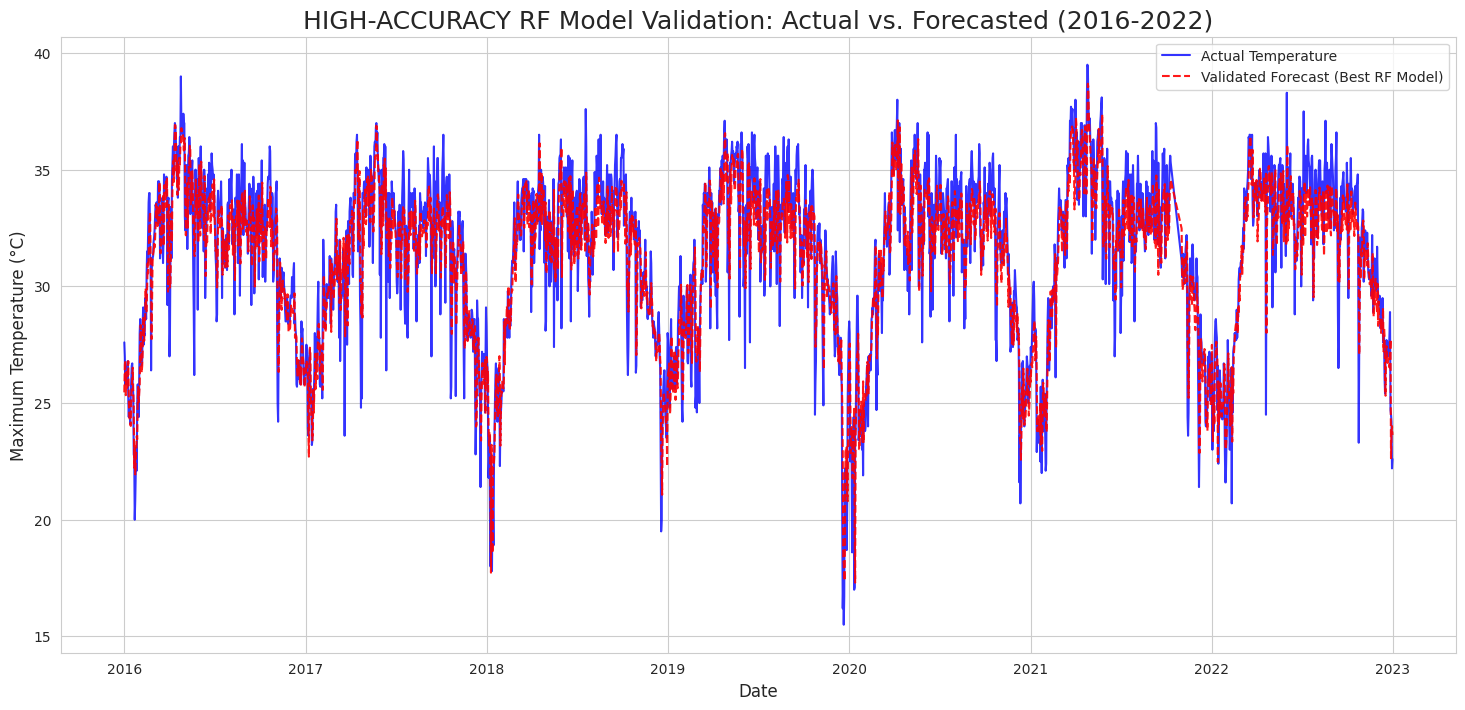

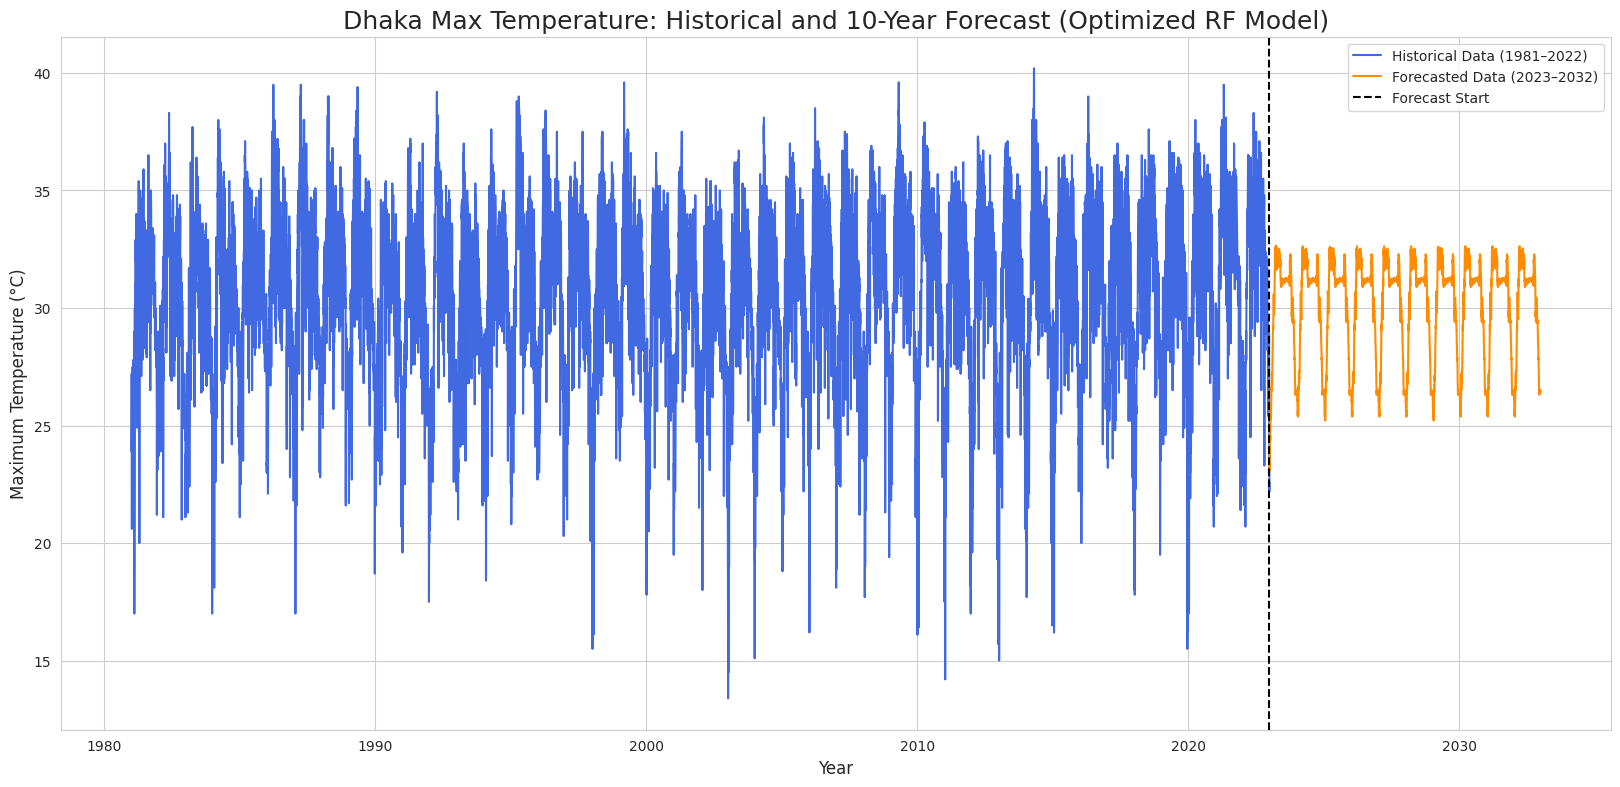

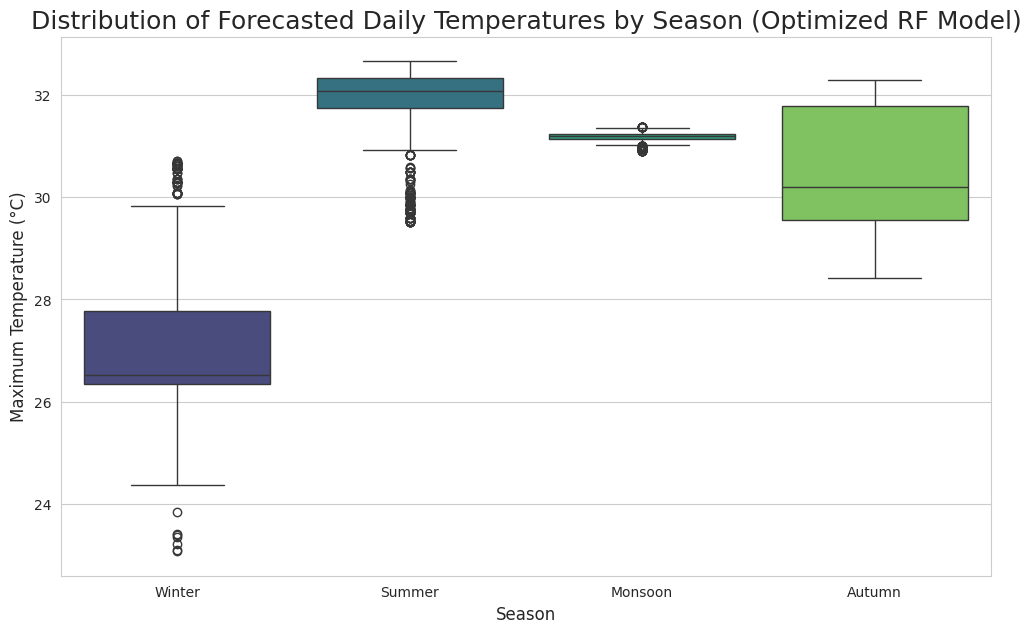

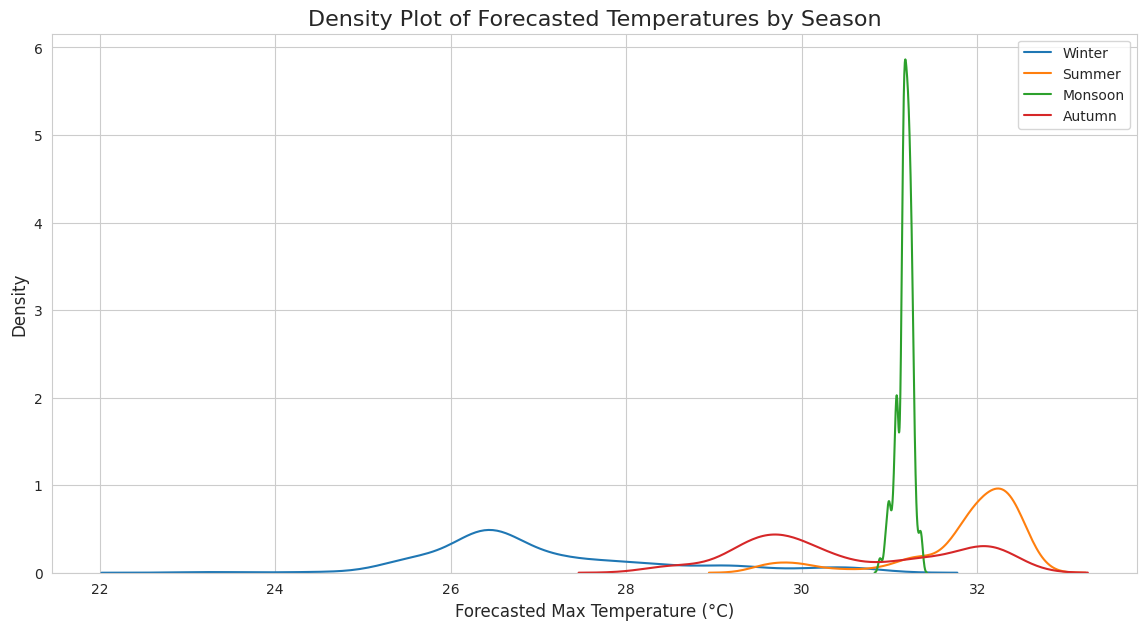


✅ All processes completed successfully. CSV files saved.


In [56]:
# 1. Assigning Season Labels
def get_season(month):
    if month in [12, 1, 2]: return 'Winter'
    elif month in [3, 4, 5]: return 'Summer'
    elif month in [6, 7, 8, 9]: return 'Monsoon'
    else: return 'Autumn'

future_df['Month'] = future_df.index.month
future_df['Year'] = future_df.index.year
future_df['Season'] = future_df['Month'].apply(get_season)

# 2. Seasonal Average per Year
yearly_seasonal_avg = future_df.groupby(['Year', 'Season'])['ForecastTemp'].mean().unstack()
yearly_seasonal_avg = yearly_seasonal_avg[['Winter', 'Summer', 'Monsoon', 'Autumn']]
print("\nTable: Forecasted Average Seasonal Temperatures (°C) by Year (Optimized RF Model)")
print(yearly_seasonal_avg.round(2))

# 3. Inter-Year Correlation & Change
corrs = []
changes = []

for y in range(future_df['Year'].min(), future_df['Year'].max()):
    if y + 1 in yearly_seasonal_avg.index:
        corr = yearly_seasonal_avg.loc[[y, y+1]].T.corr().iloc[0, 1]
        change = (yearly_seasonal_avg.loc[y+1] - yearly_seasonal_avg.loc[y]).round(2)
        corrs.append({'Year': f'{y}-{y+1}', 'Correlation': round(corr, 3)})
        changes.append({'Year': f'{y}-{y+1}', **change.to_dict()})

correlation_df = pd.DataFrame(corrs)
change_df = pd.DataFrame(changes)
print("\nTable: Year-to-Year Correlation of Seasonal Temperatures")
print(correlation_df)
print("\nTable: Year-to-Year Change in Seasonal Averages (°C)")
print(change_df)

# 4. Visualization

# Validation Plot
plt.figure(figsize=(18, 8))
plt.plot(y_test_val.index, y_test_val, label='Actual Temperature', color='blue', alpha=0.8)
plt.plot(y_test_val.index, y_pred_validation, label='Validated Forecast (Best RF Model)', color='red', linestyle='--', alpha=0.9)
plt.title('HIGH-ACCURACY RF Model Validation: Actual vs. Forecasted (2016-2022)', fontsize=18)
plt.xlabel('Date'); plt.ylabel('Maximum Temperature (°C)'); plt.legend(); plt.show()

# Historical + Forecast Plot
plt.figure(figsize=(20, 9))
plt.plot(df_final.index, df_final['MaxTemp'], label='Historical Data (1981–2022)', color='royalblue')
plt.plot(future_df.index, future_df['ForecastTemp'], label='Forecasted Data (2023–2032)', color='darkorange')
plt.title('Dhaka Max Temperature: Historical and 10-Year Forecast (Optimized RF Model)', fontsize=18)
plt.xlabel('Year'); plt.ylabel('Maximum Temperature (°C)')
plt.axvline(pd.to_datetime('2023-01-01'), color='k', linestyle='--', label='Forecast Start')
plt.legend(); plt.show()

# Seasonal Distribution Boxplot
plt.figure(figsize=(12, 7))
sns.boxplot(data=future_df, x='Season', y='ForecastTemp', order=['Winter', 'Summer', 'Monsoon', 'Autumn'], palette='viridis')
plt.title('Distribution of Forecasted Daily Temperatures by Season (Optimized RF Model)', fontsize=18)
plt.xlabel('Season'); plt.ylabel('Maximum Temperature (°C)'); plt.show()

# Seasonal Density Plot
plt.figure(figsize=(14, 7))
for season in ['Winter', 'Summer', 'Monsoon', 'Autumn']:
    sns.kdeplot(future_df[future_df['Season'] == season]['ForecastTemp'], label=season)
plt.title("Density Plot of Forecasted Temperatures by Season")
plt.xlabel("Forecasted Max Temperature (°C)")
plt.ylabel("Density")
plt.legend(); plt.show()

# 5. Saving Tables to CSV
yearly_seasonal_avg.round(2).to_csv('Forecast_Seasonal_Avg_by_Year.csv')
correlation_df.to_csv('Year_to_Year_Correlation.csv', index=False)
change_df.to_csv('Year_to_Year_Seasonal_Change.csv', index=False)

print("\n✅ All processes completed successfully. CSV files saved.")
